# Pytorch Workflow

Let's explore a an example Pytorch end-to-end workflow.

In [191]:
what_were_covering = {1: "data(prepare and load)",
                     2: "build model",
                     3: "fitting the model to date (training)",
                     4: "making predictions and evaluating a model (inference)",
                     5: "saving and loading a model",
                     6: "putting it all together"}

what_were_covering


{1: 'data(prepare and load)',
 2: 'build model',
 3: 'fitting the model to date (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model',
 6: 'putting it all together'}

In [192]:
import torch
from torch import nn # nn contains all of Pytorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check Pytorch version
torch.__version__

'1.12.1'

## 1. Data (preparing and loading)

Data can be almost anything... in machine learning.

* Excel spreadsheet
* Images of any kind
* Videos like songs or podcasts
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numberical representation
2. Build a model ato learn patterns in that numberical representation

To showcase this, Let's create some *known* data using the linear regression formula

We'll use a linear regression formula to make a stright line with known parameters

In [193]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [194]:
len(X), len(y)

(50, 50)

### Splitting data into training and testing sets(one of the most important concepts in machine learning in general)

Let's create a training and test set with our data

In [195]:
# Create a train/test split
train_split = int(0.8*len(X))
X_train = X[:train_split]
y_train = y[:train_split]
X_test = X[train_split:]
y_test = y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?

In [196]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
    """
    Plot training data, testing data, and compares predictions
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')

    # Plot test data in green
    plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

    if predictions is not None:
        # Plot predictions if they are exist
        plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

    # Show the legend
    plt.legend(prop={'size': 14});


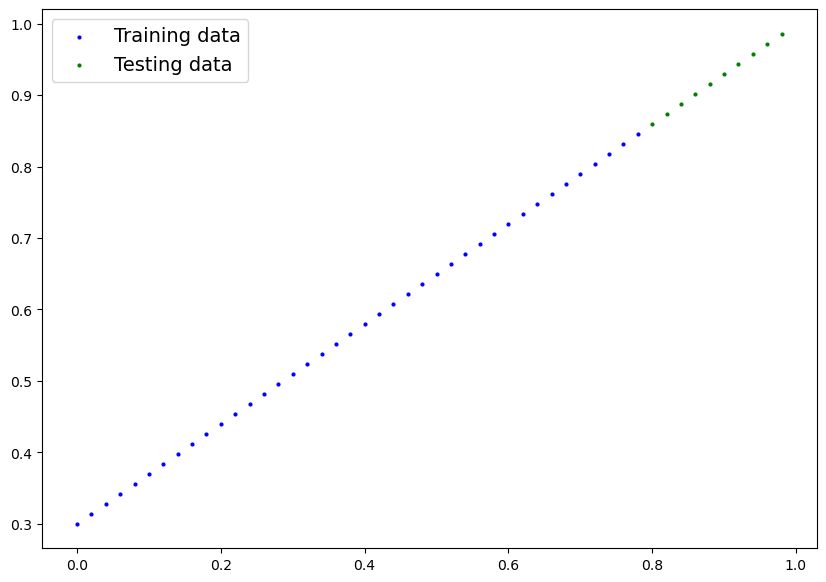

In [197]:
plot_predictions()

## 2. Build model
our first Pytorch model!

what our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to creat the data)

How does it do so?

Through two main algorighm: - videos of 3Blue1Brown
1. Gradient descent
2. Backpropagation

In [198]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): # <- almost everying in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))

        # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
        return self.weights * x + self.bias # this is the linear regression formula


### PyTorch model building essentials

* torch.nn - contains all of the buildings for computational graphs (a neural network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network models, if you subclass it, you should overwrite forward()
* torch.optim - this is where the optimizers in Pytorch live, they will help with gradient descent
* def forward() - All nn.Modele subclass require you to overwrite forward(), this method defines what happens in the forward computation

See more of these essential modules visa the PyTorch cheatsheet - https://www.learnpytorch.io/pytorch_cheatsheet/

### Checking the contents of our PyTorch model

Now we've created a mode, let's see what's inside...

So we can check our model parameters or what's inside our model using `.parameters()`

In [199]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [200]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predeiction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`

When we pass data through our model, it's going to run it through the `forward()` method.

In [201]:
# Make predictions with model
with torch.inference_mode():
    y_pred = model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

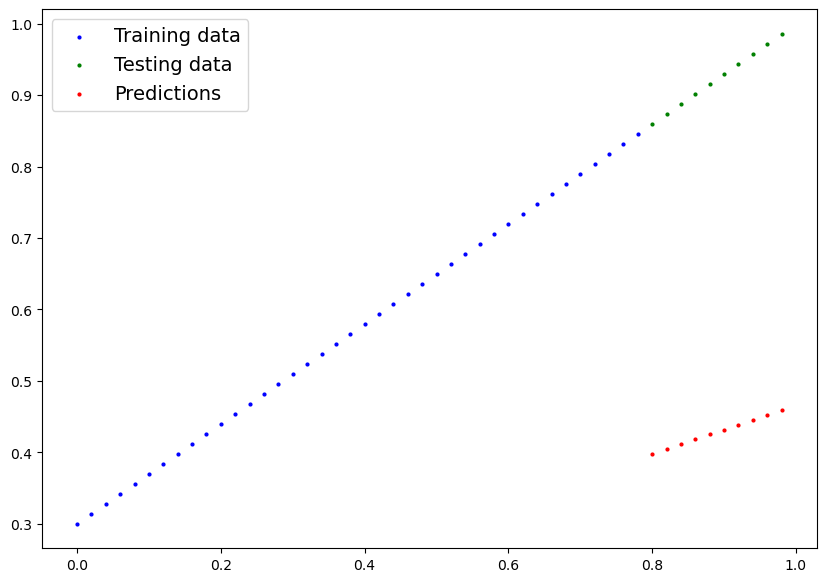

In [202]:
plot_predictions(predictions=y_pred)

## 3. Train model

The whole idea of training is for a model to move some *unknown* parameters (these may be random) to some *known* parameters.

Or in other words,from a poor representation to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias in our case) to improve the loss function.

And specification for PyTorch, we need:

* A training loop.
* A testing loop.

In [203]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.001) # lr = learning rate = possibly the most important hyperparameter you can set

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass ( this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss(**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and impore the loss(**gradient descent**)


In [204]:
# An epoch is one loop through the data... ( this is a hyperparameter because we've set it ourselves)
epochs = 1750

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 0. Loop trough the data
for epoch in range(epochs):
    # Set the model to training mode
    model_0.train() # train mode in Pytorch sets all parameters that require gradients to require gradients

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Step the optimizer(perform gradient descent)
    optimizer.step() # by dedault how the optimizer changes will acculumate through the loop so we have to zero them above in step 3 for the next iteration for the loop 

    ### Testing
    model_0.eval() # turns off different settings in the model not needed for evaluation/testing (dropout, batch norm layers)
    with torch.inference_mode(): # turns off gradient tracking & a couple more things behind the scenes
        # 1. Do the forward pass
        test_pred = model_0(X_test)

        # 2. Calculate loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)

        print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

        # Print out model state_dict()
        print(model_0.state_dict())


Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.4931890368461609
OrderedDict([('weights', tensor([0.3371])), ('bias', tensor([0.1298]))])
Epoch: 10 | Loss: 0.3013603389263153 | Test Loss: 0.4797181189060211
OrderedDict([('weights', tensor([0.3410])), ('bias', tensor([0.1398]))])
Epoch: 20 | Loss: 0.28983938694000244 | Test Loss: 0.4662471413612366
OrderedDict([('weights', tensor([0.3449])), ('bias', tensor([0.1498]))])
Epoch: 30 | Loss: 0.2783183455467224 | Test Loss: 0.4527761936187744
OrderedDict([('weights', tensor([0.3488])), ('bias', tensor([0.1598]))])
Epoch: 40 | Loss: 0.26679736375808716 | Test Loss: 0.43930521607398987
OrderedDict([('weights', tensor([0.3527])), ('bias', tensor([0.1698]))])
Epoch: 50 | Loss: 0.2552763819694519 | Test Loss: 0.4258342385292053
OrderedDict([('weights', tensor([0.3566])), ('bias', tensor([0.1798]))])
Epoch: 60 | Loss: 0.24375538527965546 | Test Loss: 0.41236335039138794
OrderedDict([('weights', tensor([0.3605])), ('bias', tensor([0.1898]))])
E

Text(0, 0.5, 'Loss')

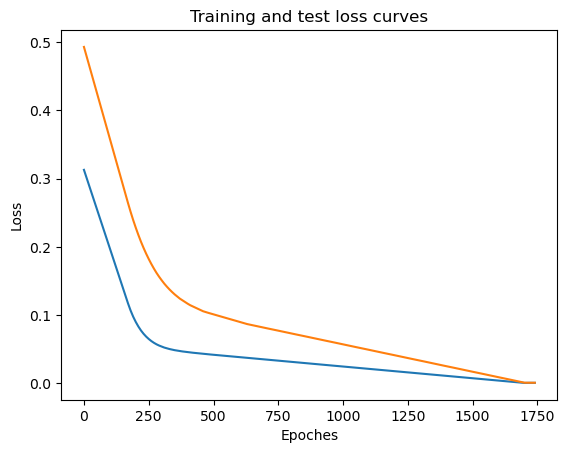

In [205]:
import numpy as np

# Plot the loss values
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Training and test loss curves") 
plt.xlabel("Epoches")
plt.ylabel("Loss")

In [206]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

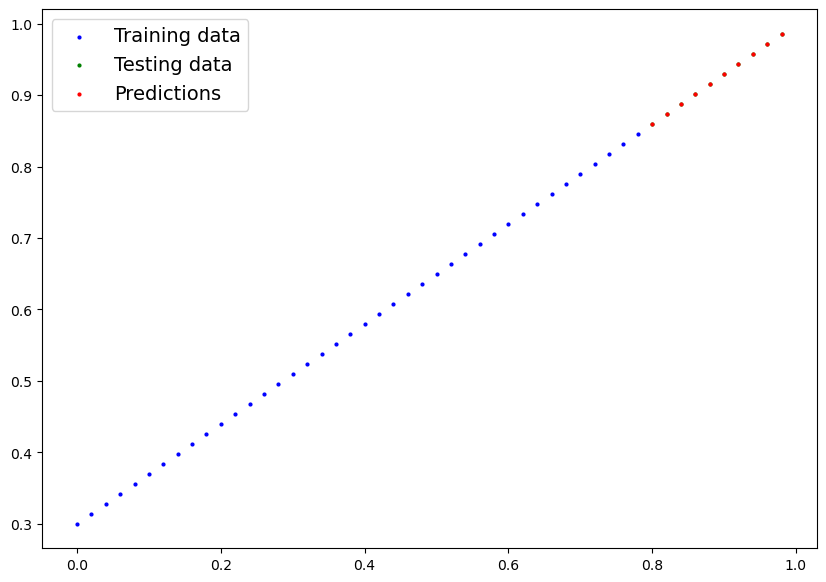

In [207]:
plot_predictions(predictions=y_preds_new)

## Saving a model in Pytorch

There are three main methods you should about for saving and loading a model in Pytorch:

1. `torch.save()` - allow you save a Pytorch object in Python's pickle format
2. `torch.load()` - allow you load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary

In [208]:
# Saving our Pytorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to : {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(),
           f = MODEL_SAVE_PATH)

Saving model to : models\01_pytorch_workflow_model_0.pth


## Loading a Pytorch model

Since we saved our model's `state_dict()` rather the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [209]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [210]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6994])), ('bias', tensor([0.2998]))])

In [211]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8593],
        [0.8733],
        [0.8873],
        [0.9013],
        [0.9152],
        [0.9292],
        [0.9432],
        [0.9572],
        [0.9712],
        [0.9852]])

In [213]:
# Make som models preds
model_0.eval()
with torch.inference_mode():
    y_pred = model_0(X_test)
y_pred

tensor([[0.8593],
        [0.8733],
        [0.8873],
        [0.9013],
        [0.9152],
        [0.9292],
        [0.9432],
        [0.9572],
        [0.9712],
        [0.9852]])

In [214]:
# Compare loaded model preds with original model preds
y_pred == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting it all together

Let's go back through the steps above and see it all in one place.

In [ ]:
# Impoer Pytorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check out pytorch version
torch.__version__

'1.12.1'

Create device-agnostic code

This means if we've got access to a GPU ,our code will use it(for potentially faster computing).

If no GPU is available,the code will default to using CPU.

In [216]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### 6.1 Data


In [217]:
# Create some data using the linear regression formula of y = weight * X + bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [218]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

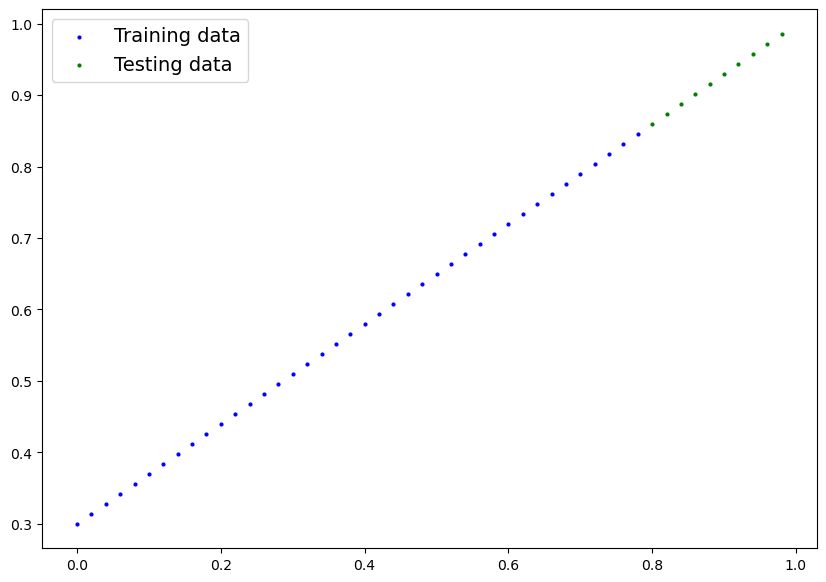

In [219]:
# Plot the data
plot_predictions(X_train, y_train, X_test, y_test)

## 6.2 Building a Pytorch Linear Model

In [220]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters / also called: linear transform, probing layer, fully connected layer, dense layer
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [221]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [222]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.3 Training

For training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop

In [233]:
# Setup loss function
loss_fn = nn.L1Loss()

# Setup our optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(), 
                            lr = 0.01)

In [236]:
# Let's write a training loop

torch.manual_seed(42)

epochs = 200

# Put data on the target device (device agnostic code for data)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2.Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        text_pred = model_1(X_test)

        test_loss = loss_fn(text_pred, y_test)

    # Print out what's happening

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")


Epoch: 0 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 10 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 20 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 30 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 40 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 50 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 60 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 70 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 80 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 90 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 100 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 110 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 120 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 130 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 140 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 150 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 160 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 170 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 180 | Loss: 0.0030 | Test Loss: 0.0133
Epoch: 190 | Loss: 0.0030 | Test Loss: 0.0133


In [237]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6943]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3052], device='cuda:0'))])

### 6.4 Making and evaluating predictions

In [238]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_pred = model_1(X_test)
y_pred

tensor([[0.8606],
        [0.8745],
        [0.8884],
        [0.9023],
        [0.9162],
        [0.9301],
        [0.9440],
        [0.9578],
        [0.9717],
        [0.9856]], device='cuda:0')

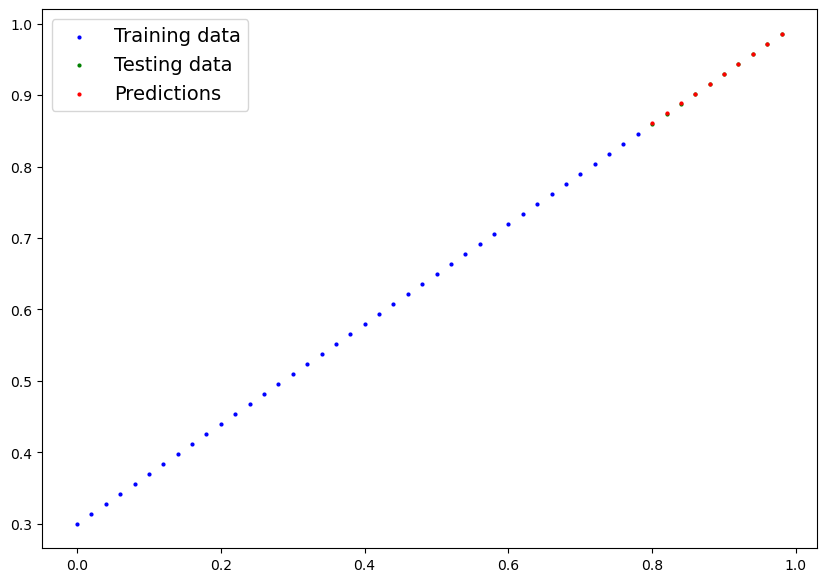

In [239]:
# Check out our model predictions visually
plot_predictions(predictions=y_pred.cpu())

### 6.5 Saving & loading a trained model

In [241]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(), 
           f = MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_workflow_model_1.pth


In [242]:
# Load a Pytorch model

# Create a new instance of linear regression model V2
loaded_model_1 = LinearRegressionModelV2()

# Load the saved model_1 state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put the loaded model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [244]:
next(loaded_model_1.parameters()).device


device(type='cuda', index=0)

In [245]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6943]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3052], device='cuda:0'))])

In [246]:
# Evaluate the loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_pred == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')